In [1]:
import csv
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from sklearn.manifold import MDS
import Levenshtein

from lib.predict.model.embedding import one_hot_vectors
from lib.utils import constants
from lib.utils.jsonl import read_jsonl

/home/kyoshida/.pyenv/versions/3.10.3/envs/esm2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_whole_seqs(db_size: str) -> list:
    whole_seqs = []
    df1 = pd.DataFrame(read_jsonl(f"../data/generated_sequences/database/{db_size}/train.jsonl"))
    df2 = pd.DataFrame(read_jsonl(f"../data/generated_sequences/database/{db_size}/valid.jsonl"))
    whole_seqs.extend(df1.sequence.tolist())
    whole_seqs.extend(df2.sequence.tolist())
    return whole_seqs

In [3]:
# WT sequence
original_seq = constants.HINGE_28 + constants.TM_28 + constants.COSTIM_28 + constants.ACTIVATION_3Z


# Plot color
cols1 = sns.color_palette("Oranges", 2)
cols2 = sns.color_palette("Blues", 2)

/home/kyoshida/.pyenv/versions/3.10.3/envs/esm2/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


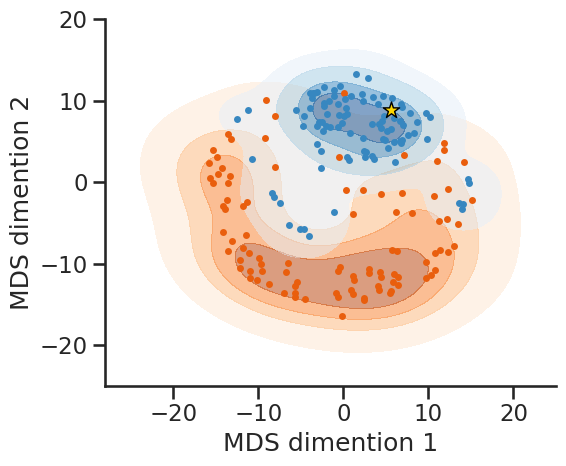

In [4]:
# MDS plot

# Sampled high- and low-diversity sequences
with open("../data/generated_sequences/representative/high_diversity_seqs.txt", "r") as f:
    high_seqs = f.readlines()
high_seqs = [seq.replace("\n", "") for seq in high_seqs]

with open("../data/generated_sequences/representative/low_diversity_seqs.txt", "r") as f:
    low_seqs = f.readlines()
low_seqs = [seq.replace("\n", "") for seq in low_seqs]


# MDS plot
whole_seqs = [original_seq]
whole_seqs.extend(high_seqs)
whole_seqs.extend(low_seqs)
enc_seqs = one_hot_vectors(whole_seqs)
mds = MDS(n_components=2, random_state=42).fit_transform(enc_seqs)

fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(ax=ax, x=mds[1:len(high_seqs)+1, 0], y=mds[1:len(high_seqs)+1, 1], levels=5, alpha=0.5, bw_method=0.5, fill=True, cmap="Oranges")
sns.kdeplot(ax=ax, x=mds[len(high_seqs)+1:, 0], y=mds[len(high_seqs)+1:, 1], levels=5, alpha=0.5, bw_method=0.5, fill=True, cmap="Blues")
sns.scatterplot(ax=ax, x=mds[1:len(high_seqs)+1,0], y=mds[1:len(high_seqs)+1,1], s=25.0, color=cols1[1], linewidth=0)
sns.scatterplot(ax=ax, x=mds[len(high_seqs)+1:,0], y=mds[len(high_seqs)+1:,1], s=25.0, color=cols2[1], linewidth=0)
sns.scatterplot(ax=ax, x=mds[:1,0], y=mds[:1,1], s=150.0, linewidth=1.0, color="gold", marker="*", edgecolors="black")
ax.set_xlim(-28, 25)
ax.set_ylim(-25, 20)
ax.set_xlabel("MDS dimention 1")
ax.set_ylabel("MDS dimention 2")
sns.despine()
fig.tight_layout()
fig.savefig("./figures/mds_plot.svg")

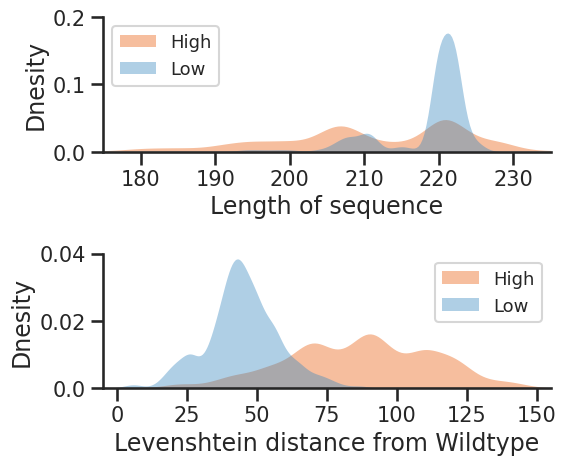

In [5]:
# Length and levenshtein distance

# high- and low-diversity sequences
distance_high = [Levenshtein.distance(seq, original_seq) for seq in get_whole_seqs("high")]
distance_low = [Levenshtein.distance(seq, original_seq) for seq in get_whole_seqs("low")]


# Compute length
length_high = [len(seq) for seq in get_whole_seqs("high")]
length_low = [len(seq) for seq in get_whole_seqs("low")]


# Compute levenshtein
distance_high = [Levenshtein.distance(seq, original_seq) for seq in get_whole_seqs("high")]
distance_low = [Levenshtein.distance(seq, original_seq) for seq in get_whole_seqs("low")]


# Plot
fig, axes = plt.subplots(2, 1, figsize=(6, 5))
sns.kdeplot(ax=axes[0], x=length_high, color=cols1[1], alpha=0.4, fill=True, linewidth=0, label="High")
sns.kdeplot(ax=axes[0], x=length_low, color=cols2[1], alpha=0.4, fill=True, linewidth=0, label="Low")
sns.kdeplot(ax=axes[1], x=distance_high, color=cols1[1], alpha=0.4, fill=True, linewidth=0, label="High")
sns.kdeplot(ax=axes[1], x=distance_low, color=cols2[1], alpha=0.4, fill=True, linewidth=0, label="Low")
axes[0].set_xlabel("Length of sequence", fontsize=17)
axes[0].set_ylabel("Dnesity", fontsize=17)
axes[0].set_xlim([175, 235])
axes[0].set_xticks(np.arange(180, 235, 10))
axes[0].set_xticklabels(np.arange(180, 235, 10), fontsize=15)
axes[0].set_ylim([0, 0.2])
axes[0].set_yticks(np.arange(0, 0.3, 0.1))
axes[0].set_yticklabels(np.arange(0, 0.3, 0.1), fontsize=15)
axes[0].legend(loc="upper left", fontsize=13)
axes[1].set_xlabel("Levenshtein distance from Wildtype", fontsize=17)
axes[1].set_ylabel("Dnesity", fontsize=17)
axes[1].set_xlim([-5, 155])
axes[1].set_xticks(np.arange(0, 175, 25))
axes[1].set_xticklabels(np.arange(0, 175, 25), fontsize=15)
axes[1].set_ylim([0, 0.04])
axes[1].set_yticks(np.arange(0, 0.06, 0.02))
axes[1].set_yticklabels(np.arange(0, 0.06, 0.02), fontsize=15)
axes[1].legend(loc="upper right", fontsize=13)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/histogram_length_and_levenshetein.svg")

In [6]:
# Diversity levels
tables = [
    {
        "Diversity": "High",
        "N": len(length_high),
        "length_ave": np.mean(length_high),
        "length_max": np.max(length_high),
        "length_min": np.min(length_high),
        "distance_ave": np.mean(distance_high),
        "distance_max": np.max(distance_high),
        "distance_min": np.min(distance_high)
    },
    {
        "Diversity": "Low",
        "N": len(length_low),
        "length_ave": np.mean(length_low),
        "length_max": np.max(length_low),
        "length_min": np.min(length_low),
        "distance_ave": np.mean(distance_low),
        "distance_max": np.max(distance_low),
        "distance_min": np.min(distance_low)
    },
]

with open("./tables/comparison_diversity_levels.csv", "w") as f:
    writer = csv.DictWriter(f, fieldnames=tables[0].keys())
    writer.writeheader()
    for table in tables:
        writer.writerow(table)